# AI5707 — Pattern Recognition and Machine Learning
## Assignment 5: Maximum Likelihood Parameter Estimation

This notebook covers **every item in the assignment**:

- **Q1(a–c):** 10,000 samples per class for three Gaussian classes; isotropic, diagonal, and full covariance data-generating structures; both shared and class-specific covariance settings.
- **Q1(d–h):** stratified 80:20 train/test split, MLE fitting, test classification, confusion matrices, decision boundaries with held-out points, and observations.
- **Q2(a–d):** read the supplied 2-D `train` and `dev` files, estimate parameters from training data, evaluate held-out data, plot boundaries and confusion matrices, ROC/AUC as an additional analysis, and observations.

**Folder setup:** keep `main.ipynb`, `train` (or `train.txt`) and `dev` (or `dev.txt` / `dev(2).txt`) in the same folder. Windows may hide `.txt` extensions. The loader checks the common names automatically. Do not use the held-out `dev` data to fit model parameters.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from scipy.special import softmax

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.precision", 4)
print("Working directory:", Path.cwd())

Working directory: d:\Storage\OneDrive\Desktop\test


## MLE model and classifier

For class \(i\), maximum-likelihood estimates are

\[
\hat{\mu}_i=\frac{1}{n_i}\sum_{k=1}^{n_i}x_k,\qquad
\hat{\Sigma}_i=\frac{1}{n_i}\sum_{k=1}^{n_i}(x_k-\hat{\mu}_i)(x_k-\hat{\mu}_i)^T.
\]

The covariance denominator is \(n_i\), not \(n_i-1\), because this is the MLE. The classifier uses Gaussian log-likelihood plus the empirical class log-prior. A small diagonal regularizer is applied only for numerical stability.

In [2]:
def fit_gaussian_classifier(X, y, covariance_type="full", shared_covariance=False, reg=1e-6):
    """Fit class-conditional Gaussian models by MLE (covariance denominator n)."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    if X.ndim != 2 or y.ndim != 1 or len(X) != len(y) or len(X) == 0:
        raise ValueError("X must be non-empty 2-D data and y a matching 1-D label array")
    if not np.isfinite(X).all():
        raise ValueError("X contains NaN or infinite feature values")
    if covariance_type not in {"isotropic", "diagonal", "full"}:
        raise ValueError("covariance_type must be isotropic, diagonal, or full")
    if reg <= 0:
        raise ValueError("reg must be positive")

    classes = np.unique(y)
    n, d = X.shape
    means, raw_covs, priors = {}, {}, {}
    for cls in classes:
        Xc = X[y == cls]
        if len(Xc) == 0:
            raise ValueError(f"No training samples for class {cls}")
        mu = Xc.mean(axis=0)
        centered = Xc - mu
        cov = centered.T @ centered / len(Xc)  # MLE denominator n_i
        means[cls], raw_covs[cls], priors[cls] = mu, cov, len(Xc) / n

    if shared_covariance:
        pooled = sum((X[y == c] - means[c]).T @ (X[y == c] - means[c]) for c in classes) / n
        if covariance_type == "isotropic":
            pooled = np.eye(d) * (np.trace(pooled) / d)
        elif covariance_type == "diagonal":
            pooled = np.diag(np.diag(pooled))
        covariances = {c: pooled.copy() for c in classes}
    else:
        covariances = {}
        for c in classes:
            cov = raw_covs[c]
            if covariance_type == "isotropic":
                cov = np.eye(d) * (np.trace(cov) / d)
            elif covariance_type == "diagonal":
                cov = np.diag(np.diag(cov))
            covariances[c] = cov

    for c in classes:
        covariances[c] = covariances[c] + reg * np.eye(d)
    return {"classes": classes, "means": means, "covariances": covariances,
            "priors": priors, "covariance_type": covariance_type,
            "shared_covariance": shared_covariance}


def gaussian_class_scores(model, X):
    X = np.asarray(X, dtype=float)
    scores = []
    for cls in model["classes"]:
        mu, cov = model["means"][cls], model["covariances"][cls]
        sign, logdet = np.linalg.slogdet(cov)
        if sign <= 0:
            raise ValueError(f"Covariance for class {cls} is not positive definite")
        delta = X - mu
        solved = np.linalg.solve(cov, delta.T).T
        log_likelihood = -0.5 * (X.shape[1] * np.log(2*np.pi) + logdet + np.sum(delta * solved, axis=1))
        scores.append(log_likelihood + np.log(model["priors"][cls]))
    return np.column_stack(scores)


def predict_gaussian(model, X):
    scores = gaussian_class_scores(model, X)
    return model["classes"][np.argmax(scores, axis=1)]


def gaussian_class_probabilities(model, X):
    return softmax(gaussian_class_scores(model, X), axis=1)


def evaluate_model(model, X_test, y_test, title, show=True):
    pred = predict_gaussian(model, X_test)
    labels = model["classes"]
    cm = confusion_matrix(y_test, pred, labels=labels)
    acc = accuracy_score(y_test, pred)
    print(f"{title}: accuracy = {acc:.4%}")
    display(pd.DataFrame(cm, index=[f"True {c}" for c in labels],
                         columns=[f"Predicted {c}" for c in labels]))
    print(classification_report(y_test, pred, labels=labels, zero_division=0))
    if show:
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(cmap="Blues", values_format="d")
        plt.title(f"Confusion matrix — {title}")
        plt.tight_layout(); plt.show()
    return pred, cm, acc


def plot_decision_boundary(model, X_test, y_test, title, max_points=3500):
    """Plot Gaussian decision regions and overlay held-out samples."""
    X_test = np.asarray(X_test); y_test = np.asarray(y_test)
    lo = X_test.min(axis=0); hi = X_test.max(axis=0)
    pad = 0.08 * np.maximum(hi - lo, 1e-6)
    x1 = np.linspace(lo[0]-pad[0], hi[0]+pad[0], 240)
    x2 = np.linspace(lo[1]-pad[1], hi[1]+pad[1], 240)
    xx, yy = np.meshgrid(x1, x2)
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = predict_gaussian(model, grid).reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, alpha=0.20, levels=len(model["classes"])+1, cmap="viridis")
    rng = np.random.default_rng(RANDOM_STATE)
    idx = np.arange(len(X_test))
    if len(idx) > max_points:
        idx = rng.choice(idx, size=max_points, replace=False)
    for cls in model["classes"]:
        m = y_test[idx] == cls
        plt.scatter(X_test[idx][m, 0], X_test[idx][m, 1], s=12, alpha=0.65, label=f"Test class {cls}")
    plt.xlabel("x"); plt.ylabel("y"); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

## Question 1 — Synthetic Gaussian data

Each of the three classes has **10,000 points**. The experiment varies both the data-generating covariance type (isotropic, diagonal, full) and whether covariance is shared across classes or differs by class. For every generated dataset, all three covariance assumptions are fitted and evaluated on a stratified 80:20 split. This yields 18 model evaluations and confusion matrices.

\n==============================================================================
Data-generating covariance: isotropic; setting: shared
Total=30000, train=24000, test=6000; per class total=10,000
Synthetic: generated isotropic, shared; fitted isotropic: accuracy = 99.9333%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,1997,3
True 3,0,1,1999


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



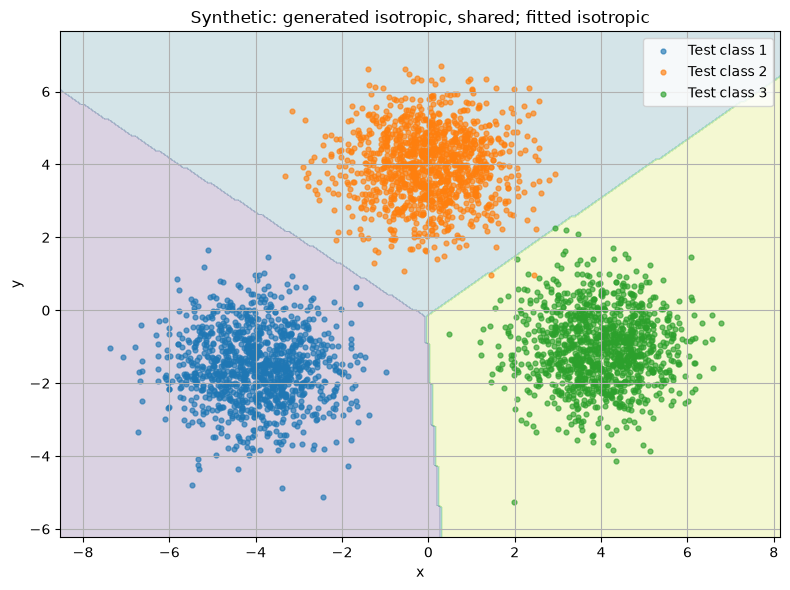

Synthetic: generated isotropic, shared; fitted diagonal: accuracy = 99.9333%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,1997,3
True 3,0,1,1999


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



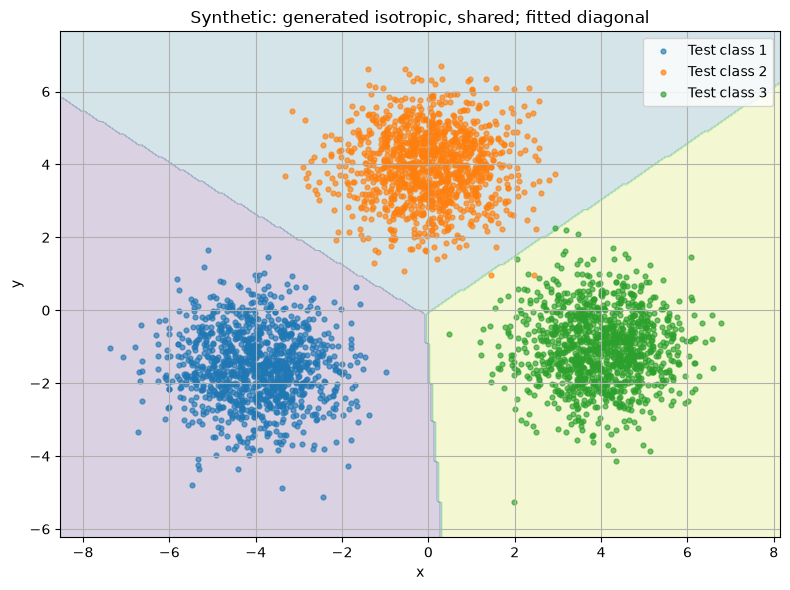

Synthetic: generated isotropic, shared; fitted full: accuracy = 99.9333%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,1997,3
True 3,0,1,1999


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



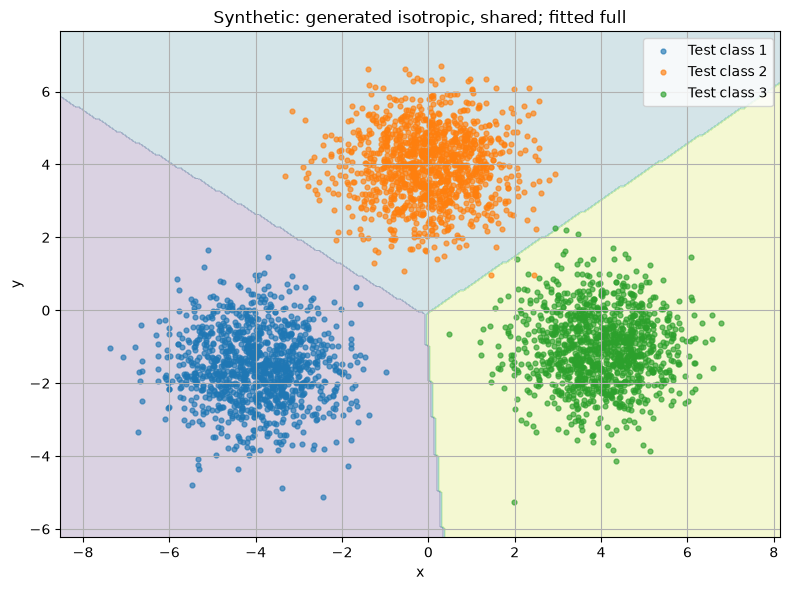

\n==============================================================================
Data-generating covariance: isotropic; setting: class-specific
Total=30000, train=24000, test=6000; per class total=10,000
Synthetic: generated isotropic, class-specific; fitted isotropic: accuracy = 99.8667%


,Predicted 1,Predicted 2,Predicted 3
True 1,1996,4,0
True 2,3,1996,1
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



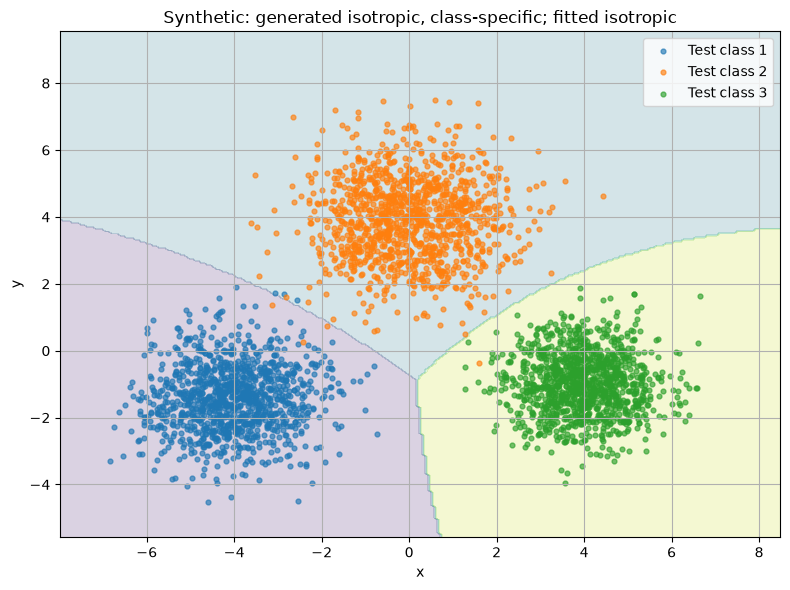

Synthetic: generated isotropic, class-specific; fitted diagonal: accuracy = 99.8667%


,Predicted 1,Predicted 2,Predicted 3
True 1,1996,4,0
True 2,3,1996,1
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



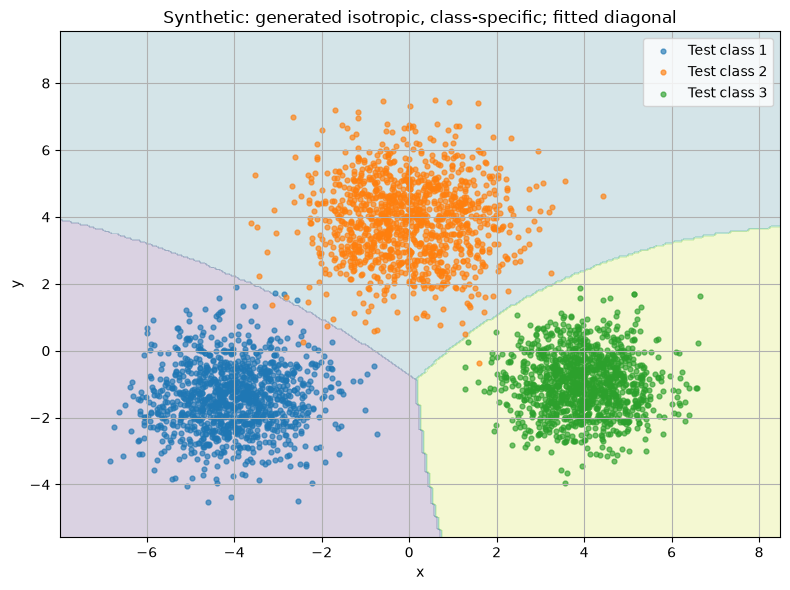

Synthetic: generated isotropic, class-specific; fitted full: accuracy = 99.8667%


,Predicted 1,Predicted 2,Predicted 3
True 1,1996,4,0
True 2,3,1996,1
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



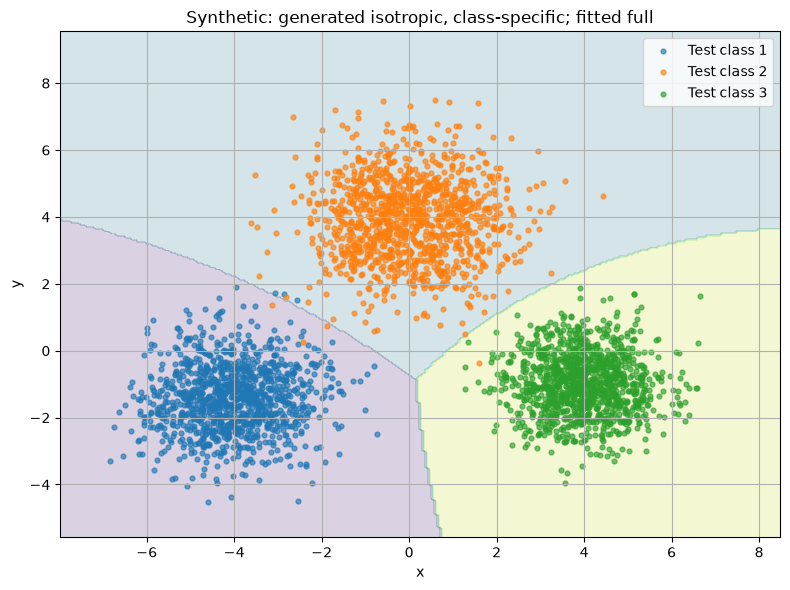

\n==============================================================================
Data-generating covariance: diagonal; setting: shared
Total=30000, train=24000, test=6000; per class total=10,000
Synthetic: generated diagonal, shared; fitted isotropic: accuracy = 99.8333%


,Predicted 1,Predicted 2,Predicted 3
True 1,1999,1,0
True 2,2,1992,6
True 3,0,1,1999


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



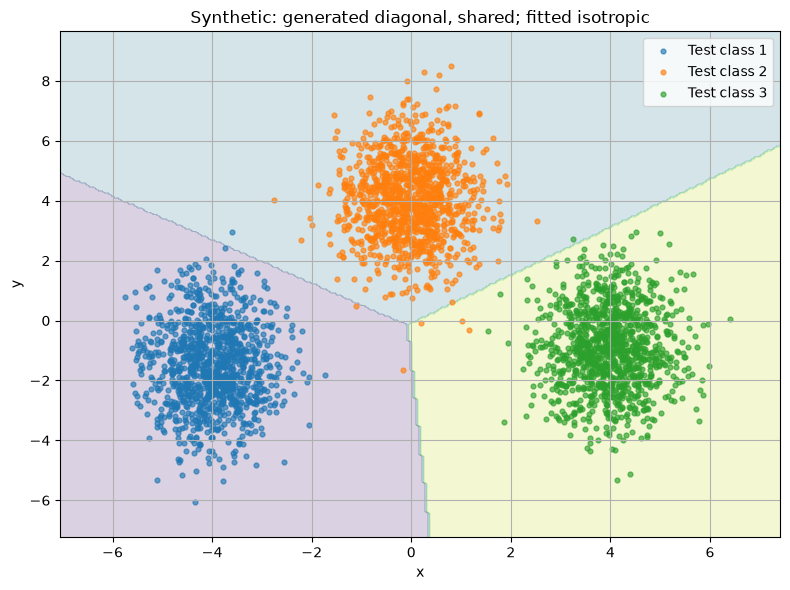

Synthetic: generated diagonal, shared; fitted diagonal: accuracy = 99.9833%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,2000,0
True 3,0,1,1999


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



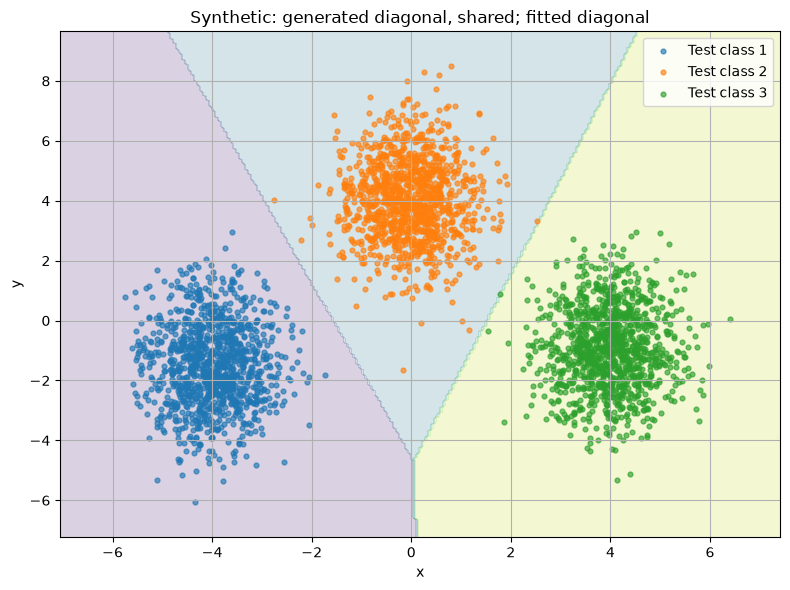

Synthetic: generated diagonal, shared; fitted full: accuracy = 99.9833%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,2000,0
True 3,0,1,1999


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



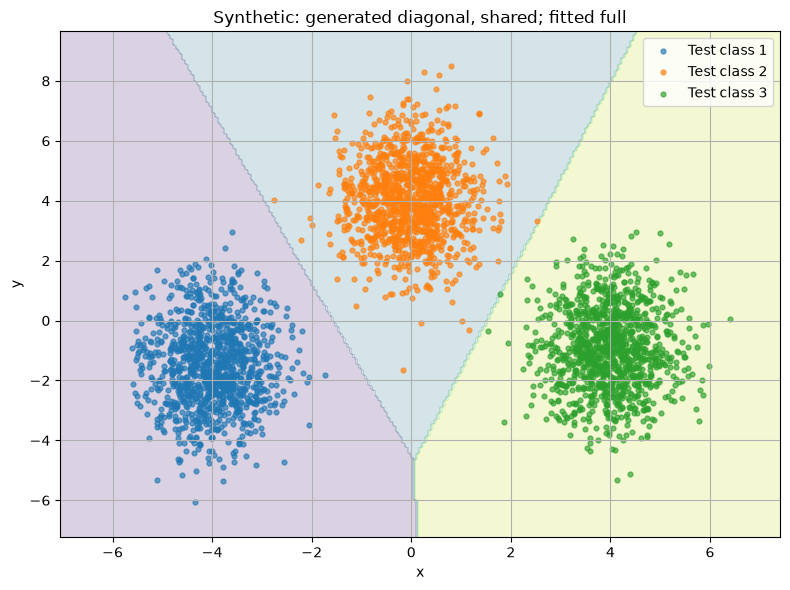

\n==============================================================================
Data-generating covariance: diagonal; setting: class-specific
Total=30000, train=24000, test=6000; per class total=10,000
Synthetic: generated diagonal, class-specific; fitted isotropic: accuracy = 99.5333%


,Predicted 1,Predicted 2,Predicted 3
True 1,1996,4,0
True 2,8,1986,6
True 3,0,10,1990


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       0.99      0.99      0.99      2000
           3       1.00      0.99      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



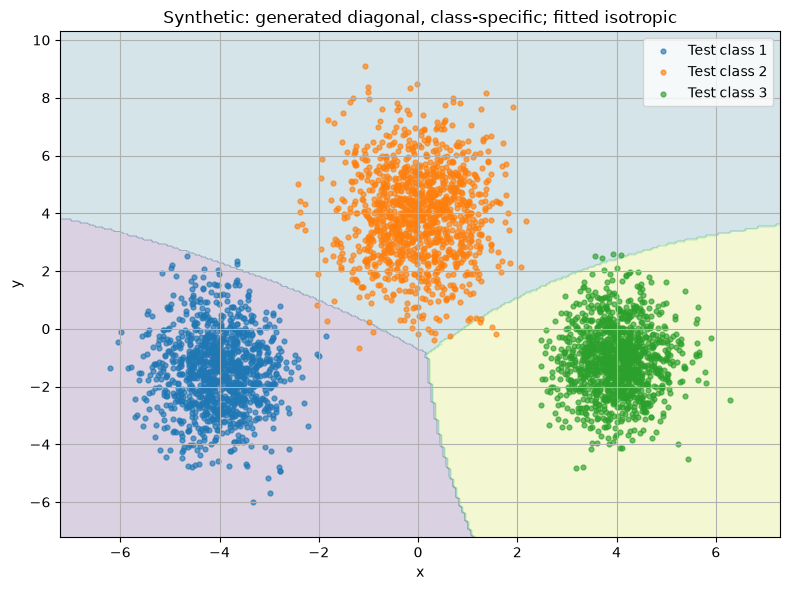

Synthetic: generated diagonal, class-specific; fitted diagonal: accuracy = 99.9833%


,Predicted 1,Predicted 2,Predicted 3
True 1,1999,1,0
True 2,0,2000,0
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



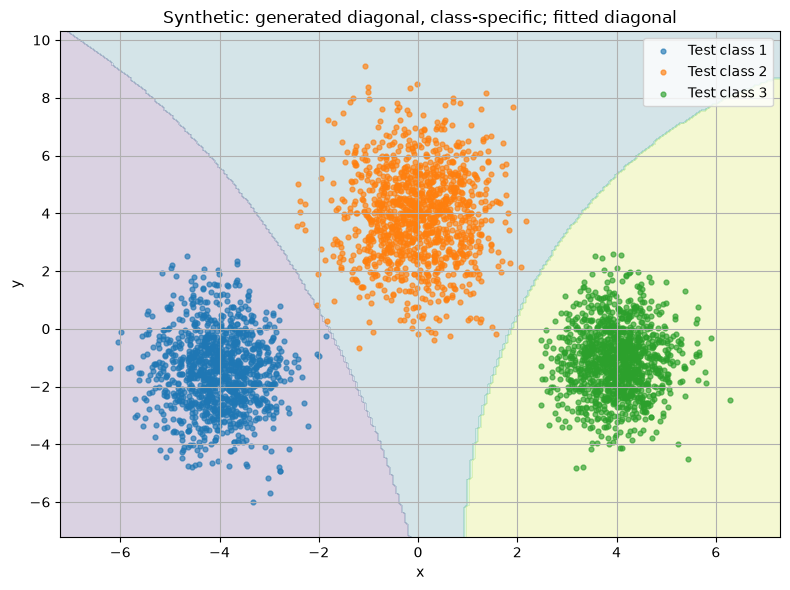

Synthetic: generated diagonal, class-specific; fitted full: accuracy = 99.9833%


,Predicted 1,Predicted 2,Predicted 3
True 1,1999,1,0
True 2,0,2000,0
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



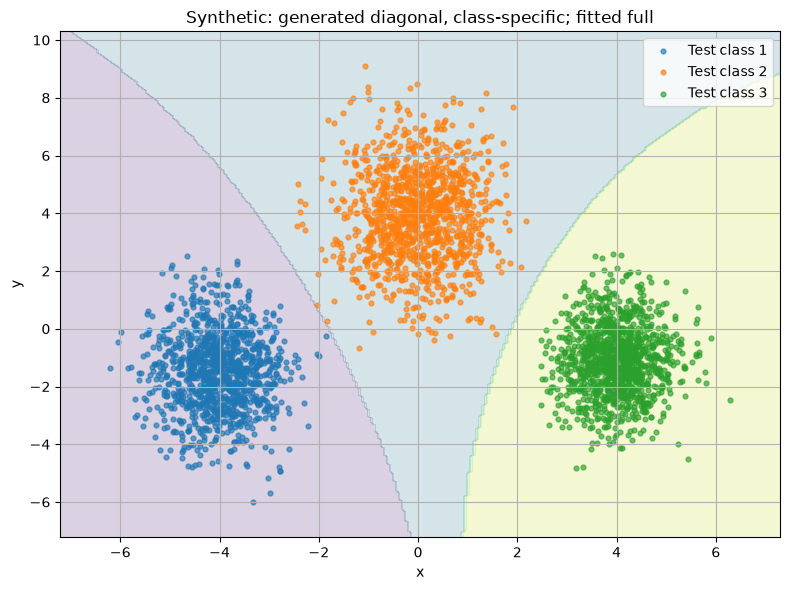

\n==============================================================================
Data-generating covariance: full; setting: shared
Total=30000, train=24000, test=6000; per class total=10,000
Synthetic: generated full, shared; fitted isotropic: accuracy = 99.4333%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,1982,18
True 3,0,16,1984


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       0.99      0.99      0.99      2000
           3       0.99      0.99      0.99      2000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



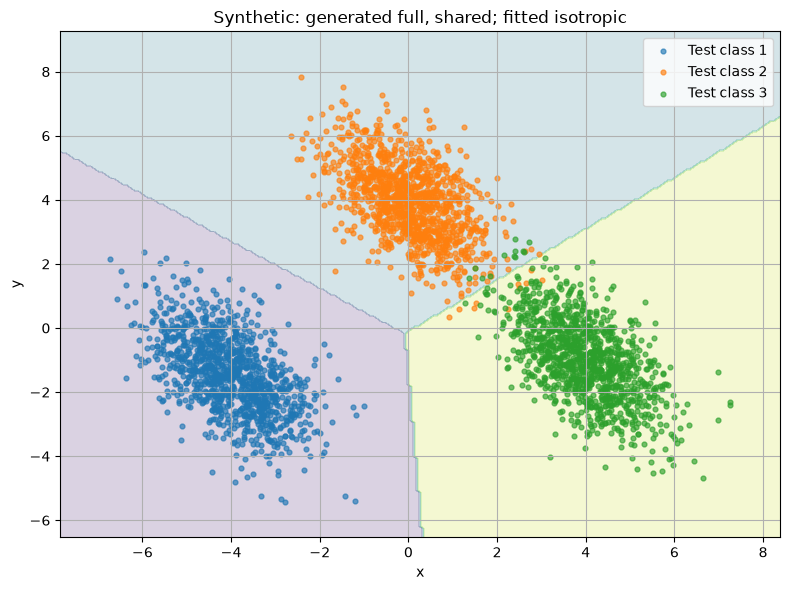

Synthetic: generated full, shared; fitted diagonal: accuracy = 99.4500%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,1986,14
True 3,0,19,1981


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       0.99      0.99      0.99      2000
           3       0.99      0.99      0.99      2000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



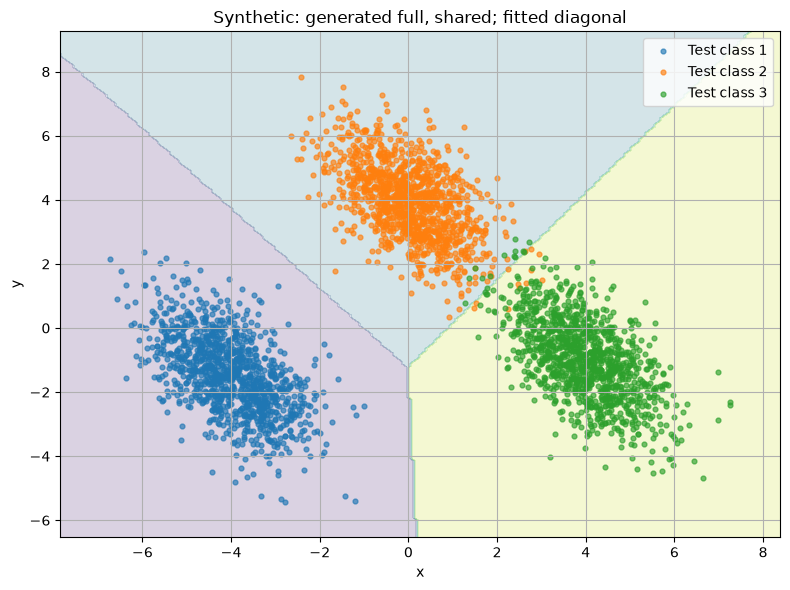

Synthetic: generated full, shared; fitted full: accuracy = 99.4167%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,0,1984,16
True 3,0,19,1981


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       0.99      0.99      0.99      2000
           3       0.99      0.99      0.99      2000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



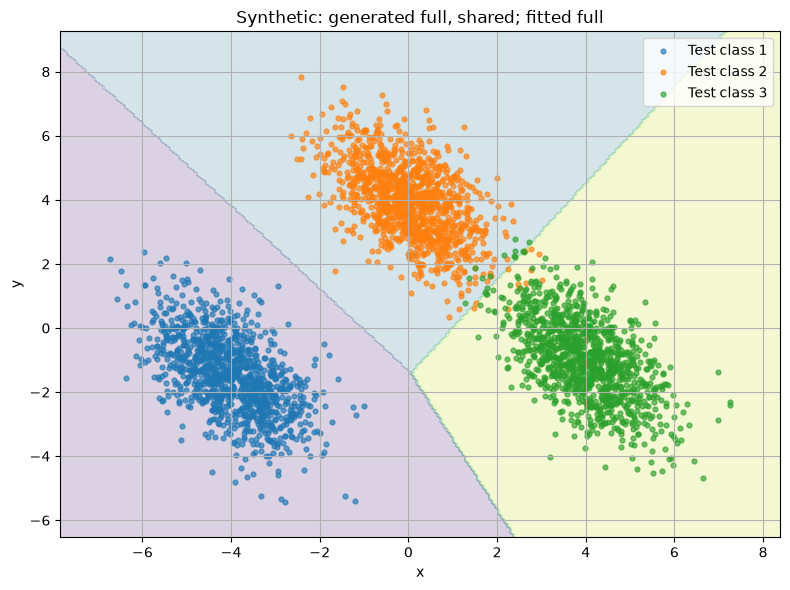

\n==============================================================================
Data-generating covariance: full; setting: class-specific
Total=30000, train=24000, test=6000; per class total=10,000
Synthetic: generated full, class-specific; fitted isotropic: accuracy = 99.6500%


,Predicted 1,Predicted 2,Predicted 3
True 1,1996,4,0
True 2,0,1983,17
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      0.99      0.99      2000
           3       0.99      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



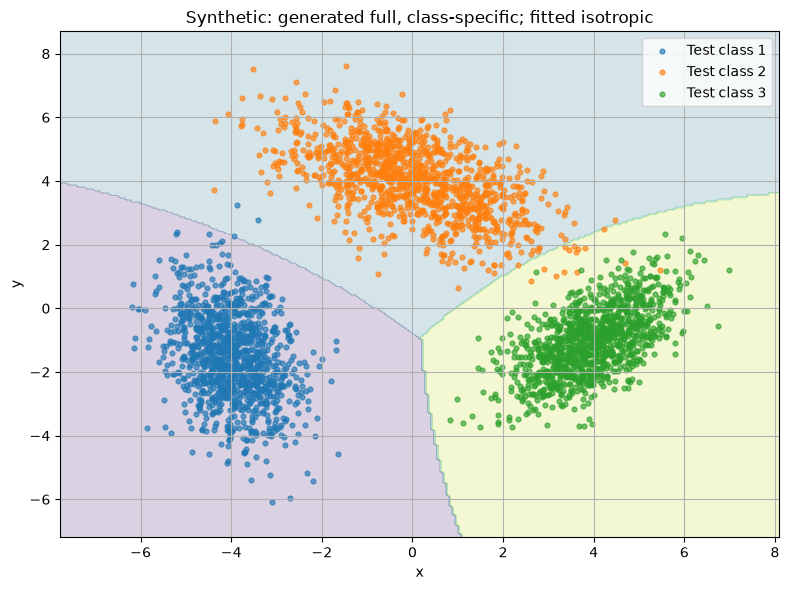

Synthetic: generated full, class-specific; fitted diagonal: accuracy = 99.6500%


,Predicted 1,Predicted 2,Predicted 3
True 1,1997,3,0
True 2,0,1982,18
True 3,0,0,2000


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      0.99      0.99      2000
           3       0.99      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



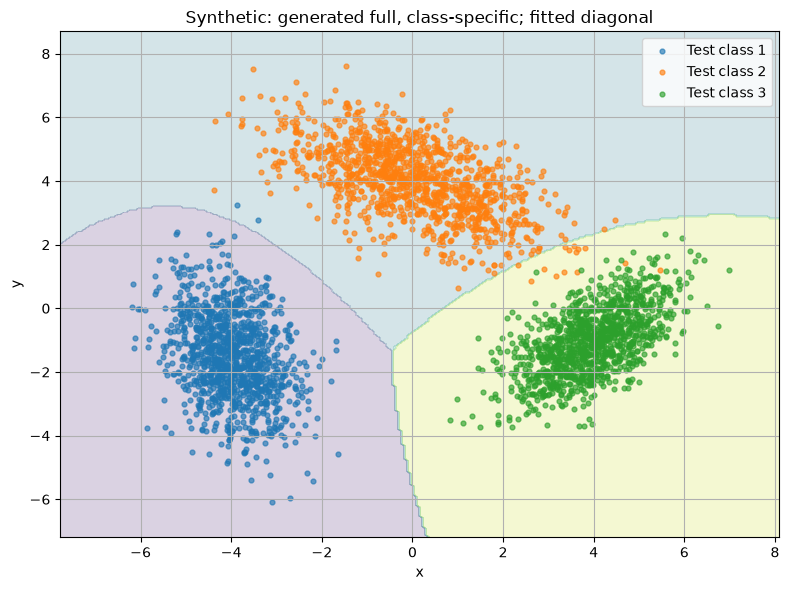

Synthetic: generated full, class-specific; fitted full: accuracy = 99.9167%


,Predicted 1,Predicted 2,Predicted 3
True 1,2000,0,0
True 2,1,1996,3
True 3,0,1,1999


              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2000
           2       1.00      1.00      1.00      2000
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



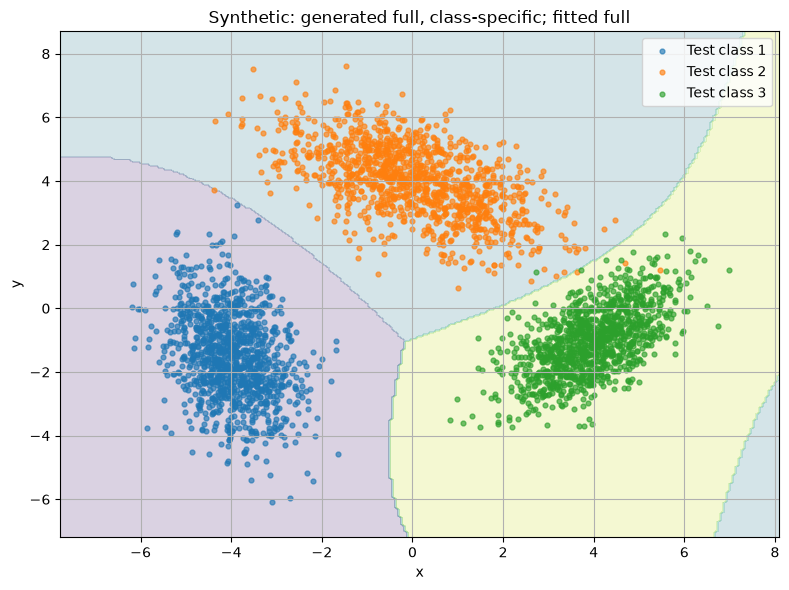

Synthetic experiment summary


,Generated covariance,Covariance setting,Fitted covariance,Test accuracy,Train samples,Test samples
0,diagonal,class-specific,diagonal,0.9998,24000,6000
1,diagonal,class-specific,full,0.9998,24000,6000
2,diagonal,class-specific,isotropic,0.9953,24000,6000
3,diagonal,shared,diagonal,0.9998,24000,6000
4,diagonal,shared,full,0.9998,24000,6000
5,diagonal,shared,isotropic,0.9983,24000,6000
6,full,class-specific,diagonal,0.9965,24000,6000
7,full,class-specific,full,0.9992,24000,6000
8,full,class-specific,isotropic,0.9965,24000,6000
9,full,shared,diagonal,0.9945,24000,6000


In [3]:
CLASSES = np.array([1, 2, 3])
SYNTHETIC_MEANS = {
    1: np.array([-4.0, -1.5]),
    2: np.array([0.0, 4.0]),
    3: np.array([4.0, -1.0]),
}


def covariance_for_generation(kind, scale=1.0, angle=0.0):
    """Create a valid 2-D isotropic, diagonal, or full covariance matrix."""
    if kind == "isotropic":
        return np.eye(2) * (1.0 * scale)
    if kind == "diagonal":
        return np.diag([0.45 * scale, 1.8 * scale])
    if kind == "full":
        c, s = np.cos(angle), np.sin(angle)
        R = np.array([[c, -s], [s, c]])
        return R @ np.diag([0.45 * scale, 1.8 * scale]) @ R.T
    raise ValueError("kind must be isotropic, diagonal, or full")


def generate_synthetic_dataset(generation_type, shared, n_per_class=10000, seed=42):
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    class_scales = {1: 1.0, 2: 1.4, 3: 0.8}
    class_angles = {1: 0.2, 2: 1.0, 3: -0.7}
    common_cov = covariance_for_generation(generation_type, 1.0, 0.55)
    for cls, mu in SYNTHETIC_MEANS.items():
        if shared:
            cov = common_cov
        else:
            cov = covariance_for_generation(generation_type, class_scales[cls], class_angles[cls])
        Xs.append(rng.multivariate_normal(mu, cov, size=n_per_class))
        ys.append(np.full(n_per_class, cls, dtype=int))
    return np.vstack(Xs), np.concatenate(ys)

synthetic_results = []
synthetic_confusion_matrices = {}
scenario_counter = 0
for generation_type in ["isotropic", "diagonal", "full"]:
    for shared in [True, False]:
        scenario_counter += 1
        X, y = generate_synthetic_dataset(generation_type, shared, n_per_class=10000,
                                          seed=RANDOM_STATE + scenario_counter)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
        setting = "shared" if shared else "class-specific"
        print("\\n" + "="*78)
        print(f"Data-generating covariance: {generation_type}; setting: {setting}")
        print(f"Total={len(X)}, train={len(X_train)}, test={len(X_test)}; per class total=10,000")
        for fitted_type in ["isotropic", "diagonal", "full"]:
            model = fit_gaussian_classifier(X_train, y_train, fitted_type, shared_covariance=shared)
            title = f"Synthetic: generated {generation_type}, {setting}; fitted {fitted_type}"
            pred, cm, acc = evaluate_model(model, X_test, y_test, title, show=False)
            synthetic_confusion_matrices[(generation_type, setting, fitted_type)] = cm
            synthetic_results.append({
                "Generated covariance": generation_type,
                "Covariance setting": setting,
                "Fitted covariance": fitted_type,
                "Test accuracy": acc,
                "Train samples": len(X_train),
                "Test samples": len(X_test),
            })
            # Required decision-boundary plot with held-out test samples for each fitted model.
            plot_decision_boundary(model, X_test, y_test, title)

synthetic_results_df = pd.DataFrame(synthetic_results)
print("Synthetic experiment summary")
display(synthetic_results_df.sort_values(["Generated covariance", "Covariance setting", "Fitted covariance"]).reset_index(drop=True))

### Question 1(h) — Synthetic-data observations

The next cell generates observations directly from the experiment results. Review them alongside the confusion matrices and plots before submission. The best model is identified separately for each generating scenario; no accuracy values are hard-coded.

In [4]:
print("OBSERVATIONS — SYNTHETIC DATA")
for (gen_type, setting), group in synthetic_results_df.groupby(["Generated covariance", "Covariance setting"]):
    group = group.sort_values("Test accuracy", ascending=False)
    best = group.iloc[0]
    print(f"• Generated={gen_type}, covariance setting={setting}: best fitted model is "
          f"{best['Fitted covariance']} (accuracy {best['Test accuracy']:.4%}).")
print("• Isotropic covariance assumes equal variance in every direction; diagonal covariance allows different "
      "feature variances but ignores correlation; full covariance models feature correlations.")
print("• Shared covariance constrains all classes to use one covariance matrix; class-specific covariance "
      "allows different class shapes. Compare these scores with the generating assumptions and confusion matrices.")

OBSERVATIONS — SYNTHETIC DATA
• Generated=diagonal, covariance setting=class-specific: best fitted model is diagonal (accuracy 99.9833%).
• Generated=diagonal, covariance setting=shared: best fitted model is diagonal (accuracy 99.9833%).
• Generated=full, covariance setting=class-specific: best fitted model is full (accuracy 99.9167%).
• Generated=full, covariance setting=shared: best fitted model is diagonal (accuracy 99.4500%).
• Generated=isotropic, covariance setting=class-specific: best fitted model is isotropic (accuracy 99.8667%).
• Generated=isotropic, covariance setting=shared: best fitted model is isotropic (accuracy 99.9333%).
• Isotropic covariance assumes equal variance in every direction; diagonal covariance allows different feature variances but ignores correlation; full covariance models feature correlations.
• Shared covariance constrains all classes to use one covariance matrix; class-specific covariance allows different class shapes. Compare these scores with the gen

## Question 2 — Supplied 2-D dataset

The assignment says each row contains `x, y, class label` and asks for MLE using 80% of the data and evaluation on the remaining 20%. The supplied folder shown for this task contains separate `train` and `dev` files, so the notebook treats these as a pre-defined training/held-out split to avoid leakage. It supports hidden `.txt` extensions and the alternate `dev(2)` name. It prints the actual ratio; if the supplied files are not approximately 80:20, verify that they are the correct team files.

Training file: train.txt (1050 rows)
Held-out file: dev.txt (300 rows)
Train proportion of combined rows: 77.78%; held-out proportion: 22.22%
Training class counts:


,count
label,
1,350
2,350
3,350


Held-out class counts:


,count
label,
1,100
2,100
3,100


Provided data — Isotropic covariance: accuracy = 82.3333%


,Predicted 1,Predicted 2,Predicted 3
True 1,74,4,22
True 2,2,87,11
True 3,9,5,86


              precision    recall  f1-score   support

           1       0.87      0.74      0.80       100
           2       0.91      0.87      0.89       100
           3       0.72      0.86      0.79       100

    accuracy                           0.82       300
   macro avg       0.83      0.82      0.82       300
weighted avg       0.83      0.82      0.82       300



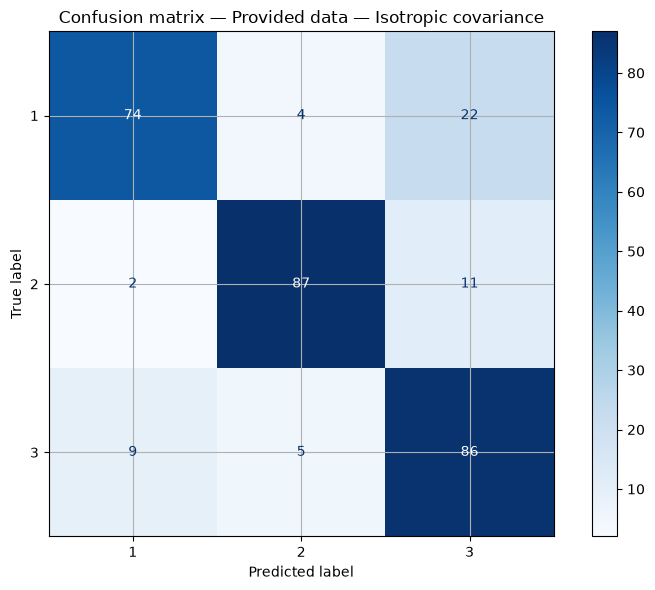

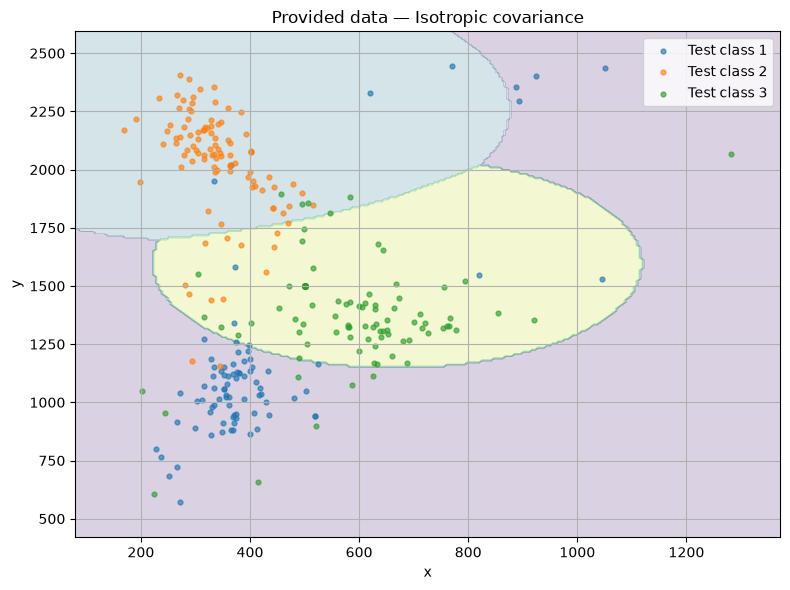

Provided data — Diagonal covariance: accuracy = 84.6667%


,Predicted 1,Predicted 2,Predicted 3
True 1,78,2,20
True 2,6,89,5
True 3,12,1,87


              precision    recall  f1-score   support

           1       0.81      0.78      0.80       100
           2       0.97      0.89      0.93       100
           3       0.78      0.87      0.82       100

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



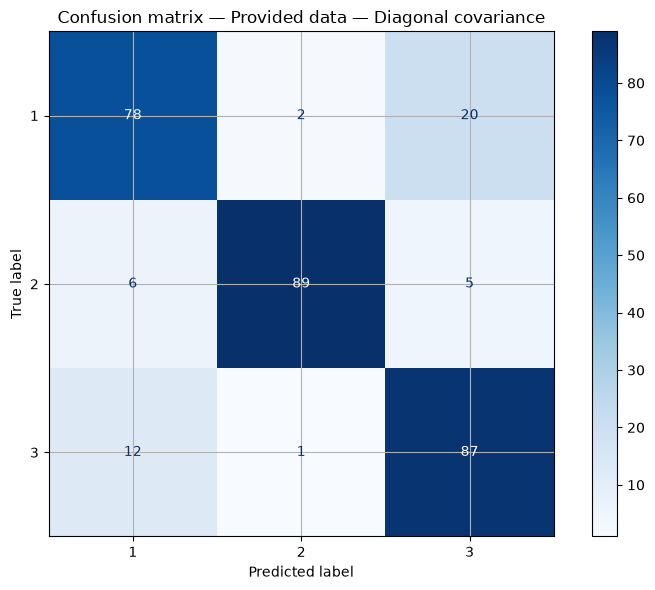

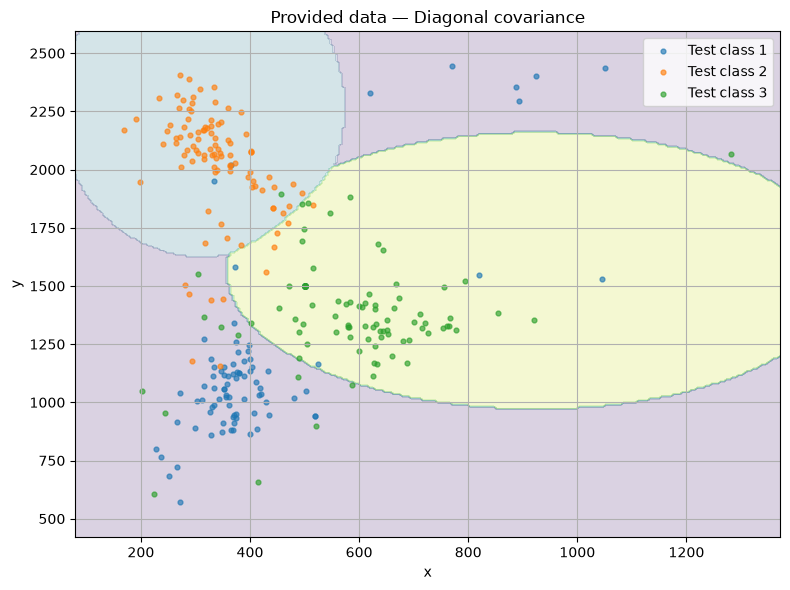

Provided data — Full covariance: accuracy = 84.3333%


,Predicted 1,Predicted 2,Predicted 3
True 1,78,2,20
True 2,6,91,3
True 3,13,3,84


              precision    recall  f1-score   support

           1       0.80      0.78      0.79       100
           2       0.95      0.91      0.93       100
           3       0.79      0.84      0.81       100

    accuracy                           0.84       300
   macro avg       0.85      0.84      0.84       300
weighted avg       0.85      0.84      0.84       300



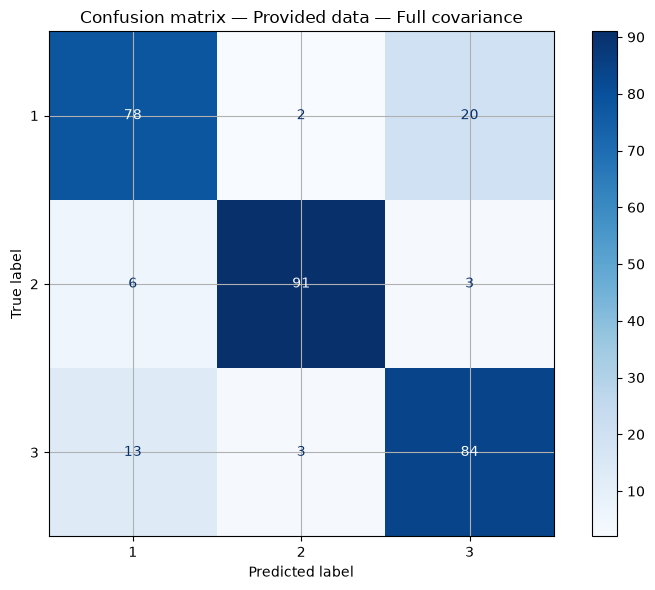

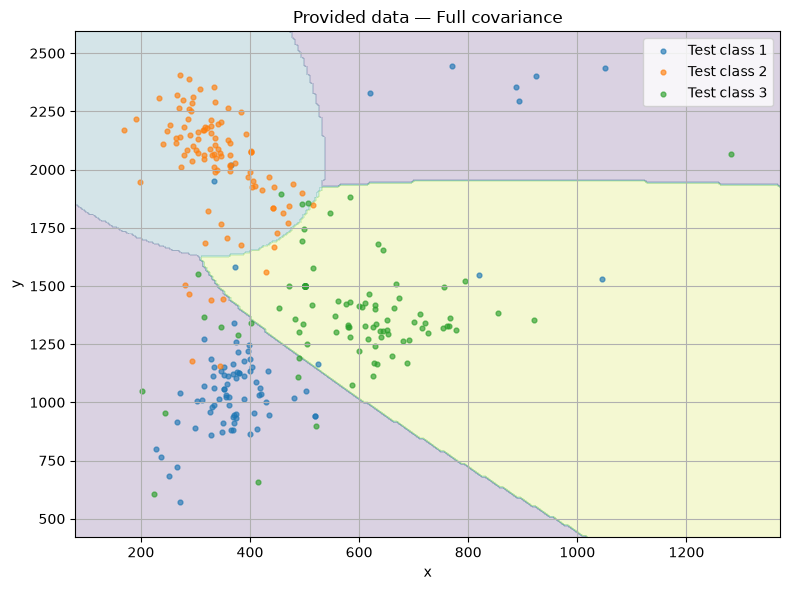

Held-out real-data model comparison


,Covariance model,Accuracy,Macro precision,Macro recall,Macro F1
0,Diagonal,0.8467,0.8522,0.8467,0.8479
1,Full,0.8433,0.8457,0.8433,0.8440
2,Isotropic,0.8233,0.8332,0.8233,0.8244


In [5]:
def locate_file(candidates):
    for name in candidates:
        p = Path(name)
        if p.is_file():
            return p
    # Case-insensitive fallback, useful on systems with unusual filename casing.
    available = {p.name.lower(): p for p in Path.cwd().iterdir() if p.is_file()}
    for name in candidates:
        if name.lower() in available:
            return available[name.lower()]
    return None

train_path = locate_file(["train.txt"])
dev_path = locate_file(["dev.txt"])


def load_dataset(path):
    # Accept comma-separated or whitespace-separated three-column data, with optional comment lines.
    df = pd.read_csv(path, header=None, comment="#", sep=r"[,\s]+", engine="python", skipinitialspace=True)
    if df.shape[1] != 3:
        raise ValueError(f"{path} must contain exactly three columns x, y, class_label; found {df.shape[1]}.")
    df.columns = ["x", "y", "label"]
    df = df.apply(pd.to_numeric, errors="coerce")
    if df.isna().any().any():
        bad = df.index[df.isna().any(axis=1)].tolist()[:10]
        raise ValueError(f"{path} has missing/non-numeric values at row indices {bad}.")
    if not np.isfinite(df[["x", "y"]].to_numpy(dtype=float)).all():
        raise ValueError(f"{path} has non-finite feature values.")
    labels = df["label"].to_numpy(dtype=float)
    if not np.equal(labels, np.floor(labels)).all():
        raise ValueError(f"{path} contains non-integer class labels.")
    df["label"] = labels.astype(int)
    if df["label"].nunique() < 2:
        raise ValueError(f"{path} must contain at least two classes.")
    return df

real_results = []
real_models = {}
real_confusion_matrices = {}
if train_path is None or dev_path is None:
    print("REAL-DATA EVALUATION PENDING: could not find both files in", Path.cwd())
    print("Found files:", sorted(p.name for p in Path.cwd().iterdir() if p.is_file()))
    print("Expected train/train.txt and dev/dev.txt (dev(2).txt is also accepted).")
    print("Place the supplied files beside main.ipynb and rerun from this cell onward.")
else:
    train_df, dev_df = load_dataset(train_path), load_dataset(dev_path)
    train_classes, dev_classes = set(train_df.label.unique()), set(dev_df.label.unique())
    if train_classes != dev_classes:
        raise ValueError(f"Train/dev class labels differ. Train={sorted(train_classes)}, dev={sorted(dev_classes)}")
    X_train_real = train_df[["x", "y"]].to_numpy(float)
    y_train_real = train_df["label"].to_numpy(int)
    X_test_real = dev_df[["x", "y"]].to_numpy(float)
    y_test_real = dev_df["label"].to_numpy(int)
    total = len(train_df) + len(dev_df)
    print(f"Training file: {train_path} ({len(train_df)} rows)")
    print(f"Held-out file: {dev_path} ({len(dev_df)} rows)")
    print(f"Train proportion of combined rows: {len(train_df)/total:.2%}; held-out proportion: {len(dev_df)/total:.2%}")
    print("Training class counts:"); display(train_df.label.value_counts().sort_index().rename("count").to_frame())
    print("Held-out class counts:"); display(dev_df.label.value_counts().sort_index().rename("count").to_frame())

    for fitted_type in ["isotropic", "diagonal", "full"]:
        model = fit_gaussian_classifier(X_train_real, y_train_real, fitted_type, shared_covariance=False)
        real_models[fitted_type] = model
        title = f"Provided data — {fitted_type.title()} covariance"
        pred, cm, acc = evaluate_model(model, X_test_real, y_test_real, title, show=True)
        real_confusion_matrices[fitted_type] = cm
        report = classification_report(y_test_real, pred, labels=model["classes"], output_dict=True, zero_division=0)
        real_results.append({
            "Covariance model": fitted_type.title(), "Accuracy": acc,
            "Macro precision": report["macro avg"]["precision"],
            "Macro recall": report["macro avg"]["recall"],
            "Macro F1": report["macro avg"]["f1-score"]
        })
        plot_decision_boundary(model, X_test_real, y_test_real, title)

    real_results_df = pd.DataFrame(real_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    print("Held-out real-data model comparison")
    display(real_results_df.style.format({c: "{:.4f}" for c in real_results_df.columns if c != "Covariance model"}))

### Additional evaluation — Multiclass ROC and AUC

ROC/AUC is not explicitly required by the assignment, but it is included as an extra evaluation. Curves use normalized posterior probabilities from the fitted Gaussian models.

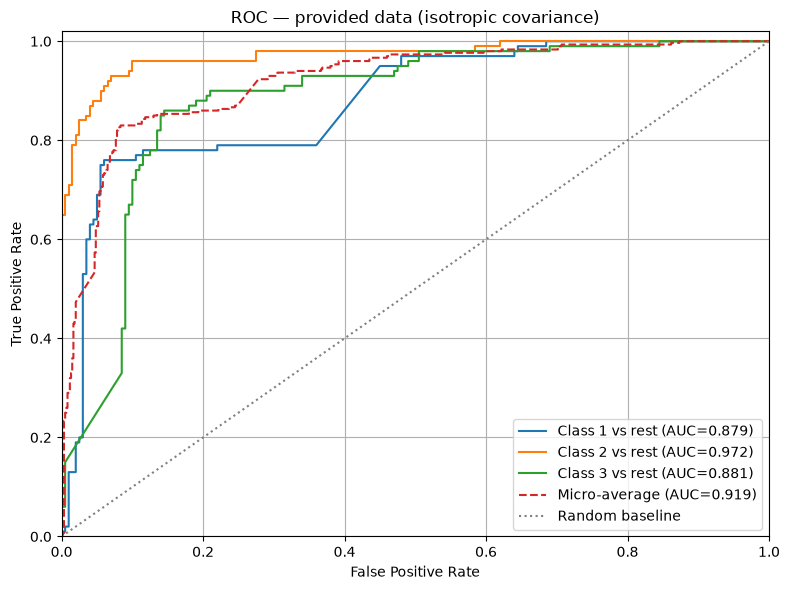

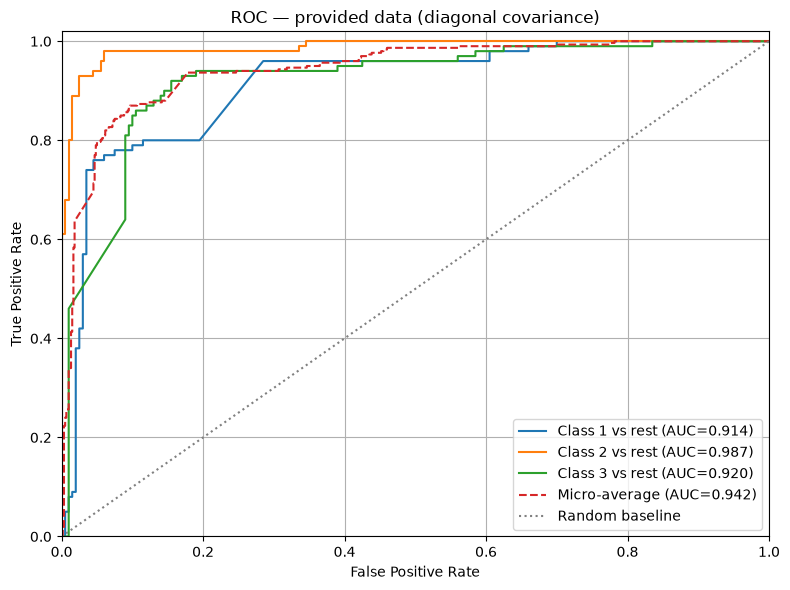

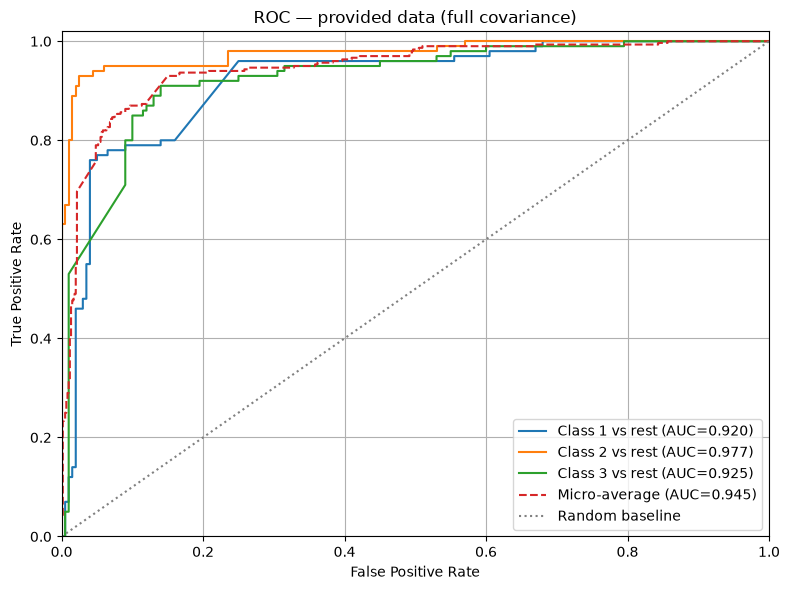

,Covariance model,Macro AUC,Micro AUC,Class 1 AUC,Class 2 AUC,Class 3 AUC
0,Isotropic,0.9105,0.9188,0.8785,0.9721,0.8808
1,Diagonal,0.9400,0.9422,0.9135,0.9866,0.9199
2,Full,0.9407,0.9450,0.9197,0.9772,0.9252


In [6]:
def plot_multiclass_roc(model, X_test, y_test, title):
    classes = model["classes"]
    probabilities = gaussian_class_probabilities(model, X_test)
    y_bin = label_binarize(y_test, classes=classes)
    if len(classes) == 2:
        y_bin = np.column_stack([1 - y_bin[:, 0], y_bin[:, 0]])
    per_class = {}
    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        if np.unique(y_bin[:, i]).size < 2:
            print(f"ROC undefined for class {cls}: held-out labels do not contain both outcomes.")
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], probabilities[:, i])
        per_class[str(cls)] = float(auc(fpr, tpr))
        plt.plot(fpr, tpr, label=f"Class {cls} vs rest (AUC={per_class[str(cls)]:.3f})")
    if np.unique(y_bin.ravel()).size == 2:
        fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probabilities.ravel())
        micro_auc = float(auc(fpr_micro, tpr_micro))
        plt.plot(fpr_micro, tpr_micro, linestyle="--", label=f"Micro-average (AUC={micro_auc:.3f})")
    else:
        micro_auc = np.nan
    macro_auc = float(np.mean(list(per_class.values()))) if per_class else np.nan
    plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Random baseline")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.xlim(0, 1); plt.ylim(0, 1.02)
    plt.legend(loc="lower right"); plt.tight_layout(); plt.show()
    return {"Per-class AUC": per_class, "Macro AUC": macro_auc, "Micro AUC": micro_auc}

if real_models:
    roc_rows = []
    for fitted_type, model in real_models.items():
        auc_result = plot_multiclass_roc(model, X_test_real, y_test_real,
                                         f"ROC — provided data ({fitted_type} covariance)")
        roc_rows.append({"Covariance model": fitted_type.title(),
                         "Macro AUC": auc_result["Macro AUC"],
                         "Micro AUC": auc_result["Micro AUC"],
                         **{f"Class {c} AUC": auc_result["Per-class AUC"].get(str(c), np.nan)
                            for c in model["classes"]}})
    roc_results_df = pd.DataFrame(roc_rows)
    display(roc_results_df.style.format({c: "{:.4f}" for c in roc_results_df.columns if c != "Covariance model"}))
else:
    print("ROC/AUC pending: it will run automatically after both real-data files are detected.")

### Question 2(d) — Real-data observations and final checklist

The next cell writes a concise observations summary from the actual held-out metrics if the dataset is present. Review it with the plots before submitting. If the data files are absent, the notebook explicitly reports that Question 2 is still pending rather than inventing results.

In [7]:
print("FINAL ASSIGNMENT STATUS")
print("Q1(a): 10,000 samples per class generated: DONE")
print("Q1(b): isotropic, diagonal, full data-generating covariance structures: DONE")
print("Q1(c): shared and class-specific covariance settings: DONE")
print("Q1(d): stratified 80:20 synthetic split: DONE")
print("Q1(e): classify held-out synthetic data: DONE")
print("Q1(f): decision boundaries with held-out test points: DONE")
print("Q1(g): confusion matrices: DONE")
print("Q1(h): synthetic observations: DONE")
if real_models:
    best = real_results_df.iloc[0]
    print("Q2(a-c): supplied data loaded, fitted and evaluated: DONE")
    print(f"Q2(d): best real-data model is {best['Covariance model']} "
          f"(held-out accuracy {best['Accuracy']:.4%}, macro-F1 {best['Macro F1']:.4f}).")
    print("Interpret the real-data confusion matrices, class-wise recall and decision boundaries above.")
    if 'roc_results_df' in globals():
        best_roc = roc_results_df.sort_values("Macro AUC", ascending=False).iloc[0]
        print(f"Additional ROC analysis: highest macro-AUC model is {best_roc['Covariance model']} "
              f"(macro-AUC {best_roc['Macro AUC']:.4f}).")
else:
    print("Q2(a-d): PENDING — put the correct train and dev files beside this notebook, then rerun all cells.")
print("Important: do not submit while Q2 is marked PENDING.")

FINAL ASSIGNMENT STATUS
Q1(a): 10,000 samples per class generated: DONE
Q1(b): isotropic, diagonal, full data-generating covariance structures: DONE
Q1(c): shared and class-specific covariance settings: DONE
Q1(d): stratified 80:20 synthetic split: DONE
Q1(e): classify held-out synthetic data: DONE
Q1(f): decision boundaries with held-out test points: DONE
Q1(g): confusion matrices: DONE
Q1(h): synthetic observations: DONE
Q2(a-c): supplied data loaded, fitted and evaluated: DONE
Q2(d): best real-data model is Diagonal (held-out accuracy 84.6667%, macro-F1 0.8479).
Interpret the real-data confusion matrices, class-wise recall and decision boundaries above.
Additional ROC analysis: highest macro-AUC model is Full (macro-AUC 0.9407).
Important: do not submit while Q2 is marked PENDING.
